In [10]:
from __future__ import annotations

import csv
import os
import random
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import transformers
from hydra import compose, initialize_config_dir
from omegaconf import open_dict

from asrq.calibration.base import CalibConfig
from asrq.core.model import ModelQ
from asrq.quantizers.base import QuantConfig
from asrq.transforms.rotation.parakeet_ctc_utils import (
    ParakeetCalibrationDataset,
    _ParakeetRotationSearchAdapter,
    modify_parakeet_ctc_layers_with_rotation_params,
    monkey_patch_parakeet_ctc_for_train,
    parakeet_ctc_collate_fn,
    prepare_parakeet_ctc_for_rotation,
)
from asrq.transforms.rotation.search import (
    RotationSearchSite,
    normalized_hadamard_matrix,
    random_sign_candidate,
)
from asrq.transforms.rotation.utils import STEQuantize, get_orthogonal_matrix, set_rotation_fake_quant_state

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
CONFIG_DIR = ROOT / "asrq" / "configs"
OUTPUT_DIR = ROOT / "outputs" / "analysis" / "parakeet_q2_search_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
LAYER_INDEX = 20
NUM_CANDIDATES = 128
CALIBRATION_NUM_SAMPLES = 16
ANALYSIS_BATCH_SIZE = 1
WEIGHT_BITS = 4
ACTIVATION_BITS = 8

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

def set_seed(seed: int = SEED) -> None:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    transformers.set_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Using device: {DEVICE}")
print(f"Artifacts will be saved to: {OUTPUT_DIR}")


Using device: cuda
Artifacts will be saved to: /home/blessedg/asrq/outputs/analysis/parakeet_q2_search_analysis


In [11]:
def build_cfg(calibration_num_samples: int) -> object:
    with initialize_config_dir(version_base=None, config_dir=str(CONFIG_DIR)):
        cfg = compose(
            config_name="config",
            overrides=[
                "model=parakeet",
                "quantizer=gptq",
                f"quantizer.bits={WEIGHT_BITS}",
                f"activation_bits={ACTIVATION_BITS}",
                "evaluate=false",
                f"calibration.num_samples={calibration_num_samples}",
                "transform=rotation",
            ],
        )
    with open_dict(cfg.quantizer):
        cfg.quantizer.exclude_modules = cfg.model.exclude_modules
    with open_dict(cfg.transform):
        cfg.transform.model_name = cfg.model.name
        cfg.transform.wbits = cfg.quantizer.bits
        cfg.transform.abits = cfg.activation_bits
        cfg.transform.learn_rotation = False
    return cfg


def build_parakeet_analysis_bundle(
    *,
    layer_index: int,
    calibration_num_samples: int,
    batch_size: int,
    device: str,
    seed: int,
) -> dict[str, object]:
    cfg = build_cfg(calibration_num_samples)
    quant_cfg = QuantConfig.from_dictconfig(cfg.quantizer)
    calib_cfg = CalibConfig.from_dictconfig(cfg.calibration)
    modelQ = ModelQ.from_pretrained(cfg.model.name, quant_cfg, calib_cfg)
    model = modelQ.model.to(device)
    model.eval()

    with torch.no_grad():
        prepare_parakeet_ctc_for_rotation(model)

    encoder_hidden_size = model.encoder.layers[0].conv.d_model
    num_encoder_layers = len(model.encoder.layers)

    qe = get_orthogonal_matrix(encoder_hidden_size, mode="hadamard", device=device, seed=seed)
    qe_param = torch.nn.Parameter(qe.float(), requires_grad=False)

    q2_params: dict[str, torch.nn.Parameter] = {}
    site: RotationSearchSite | None = None
    generator = torch.Generator().manual_seed(seed)

    for i in range(num_encoder_layers):
        head_dim = model.encoder.layers[i].self_attn.d_k
        base_h = normalized_hadamard_matrix(head_dim)
        candidate = random_sign_candidate(head_dim, generator)
        stem = f"encoder.layers.{i}.self_attn"
        q2_tensor = candidate.to_rotation(base_h, device=device, dtype=torch.float64)
        q2_params[stem] = torch.nn.Parameter(q2_tensor, requires_grad=False)
        if i == layer_index:
            site = RotationSearchSite(
                site_id=stem,
                block_id=f"encoder.layers.{i}",
                dimension=head_dim,
                base_h=base_h,
                current_candidate=candidate,
            )

    assert site is not None

    modify_parakeet_ctc_layers_with_rotation_params(
        model,
        qe_param,
        q2_params,
        include_activation_quant=False,
    )
    monkey_patch_parakeet_ctc_for_train(model, qe_param)
    set_rotation_fake_quant_state(
        model,
        enabled=False,
        activation_bits=ACTIVATION_BITS,
        weight_bits=WEIGHT_BITS,
    )

    calib_ds = ParakeetCalibrationDataset(model, num_samples=calibration_num_samples, seed=seed)
    pad_id = model.tokenizer.pad_id if hasattr(model.tokenizer, "pad_id") and model.tokenizer.pad_id > 0 else 0
    collate_fn = partial(parakeet_ctc_collate_fn, pad_id=pad_id)
    train_loader = torch.utils.data.DataLoader(
        calib_ds,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=True,
    )
    calibration_batches = [{k: v.to(device) for k, v in batch.items()} for batch in train_loader]

    adapter = _ParakeetRotationSearchAdapter(
        model,
        calibration_batches,
        q2_params,
        [site],
        device=device,
        weight_bits=WEIGHT_BITS,
        activation_bits=ACTIVATION_BITS,
    )
    adapter.refresh_caches()

    return {
        "cfg": cfg,
        "model": model,
        "adapter": adapter,
        "site": site,
        "q2_params": q2_params,
        "qe_param": qe_param,
        "calibration_batches": calibration_batches,
    }


In [12]:
bundle = build_parakeet_analysis_bundle(
    layer_index=LAYER_INDEX,
    calibration_num_samples=CALIBRATION_NUM_SAMPLES,
    batch_size=ANALYSIS_BATCH_SIZE,
    device=DEVICE,
    seed=SEED,
)

adapter = bundle["adapter"]
site = bundle["site"]
model = bundle["model"]
print(f"Prepared analysis bundle for site: {site.site_id}")
print(f"Number of cached calibration batches: {len(bundle['calibration_batches'])}")


Loading calibration samples: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 2466.15it/s]


Starting fusion of normalization weights and biases into adjacent linear layers...
Found 210 norm layers to process.
Fused normalization weights and biases into adjacent linear layers.
Prepared analysis bundle for site: encoder.layers.20.self_attn
Number of cached calibration batches: 16


In [13]:
def tensor_kurtosis(x: torch.Tensor, eps: float = 1e-12) -> float:
    flat = x.reshape(-1).float()
    centered = flat - flat.mean()
    var = centered.pow(2).mean()
    fourth = centered.pow(4).mean()
    return float(fourth / (var.pow(2) + eps))


def p99_over_rms(x: torch.Tensor, eps: float = 1e-12) -> float:
    flat = x.reshape(-1).float().abs()
    p99 = torch.quantile(flat, 0.99)
    rms = torch.sqrt(torch.mean(flat.pow(2)) + eps)
    return float(p99 / rms)


def max_over_rms(x: torch.Tensor, eps: float = 1e-12) -> float:
    flat = x.reshape(-1).float().abs()
    rms = torch.sqrt(torch.mean(flat.pow(2)) + eps)
    return float(flat.max() / rms)


def relative_activation_fakequant_mse(x: torch.Tensor, bit: int, eps: float = 1e-12) -> float:
    rows = x.reshape(-1, x.shape[-1]).float()
    q = STEQuantize.apply(rows, bit, True)
    num = torch.mean((rows - q).pow(2))
    den = torch.mean(rows.pow(2)) + eps
    return float(num / den)


def rankdata(values: np.ndarray) -> np.ndarray:
    order = np.argsort(values)
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(len(values), dtype=np.float64)
    return ranks


def spearman_corr(x: list[float], y: list[float]) -> float:
    x_arr = np.asarray(x, dtype=np.float64)
    y_arr = np.asarray(y, dtype=np.float64)
    xr = rankdata(x_arr)
    yr = rankdata(y_arr)
    return float(np.corrcoef(xr, yr)[0, 1])


def value_path_tensor_for_candidate(adapter, site, candidate) -> torch.Tensor:
    block = adapter._named_modules[site.block_id]
    linear_v = block.self_attn.linear_v
    q2 = candidate.to_rotation(site.base_h, device=linear_v.weight.device, dtype=torch.float64)
    collected = []
    with torch.no_grad():
        for kwargs in adapter._current_site_inputs:
            x = kwargs["x"]
            v = F.linear(x, linear_v.weight, linear_v.bias)
            v_heads = v.reshape(*v.shape[:-1], -1, site.dimension)
            # print(f"x.shape {x.shape} w {linear_v.weight.shape} v_heads {v_heads.shape} v_rot {v_rot.shape}")
            v_rot = torch.matmul(v_heads.to(q2.dtype), q2).to(v.dtype)
            collected.append(v_rot.detach().cpu())
    return torch.cat([t.reshape(-1, site.dimension) for t in collected], dim=0)


def evaluate_candidate(adapter, site, candidate, candidate_index: int) -> dict[str, float | int]:
    v_rot = value_path_tensor_for_candidate(adapter, site, candidate)
    nmse = adapter.score_site_candidate(site, candidate)
    return {
        "candidate_index": candidate_index,
        "block_nmse": float(nmse),
        "kurtosis": tensor_kurtosis(v_rot),
        "p99_over_rms": p99_over_rms(v_rot),
        "max_over_rms": max_over_rms(v_rot),
        "activation_rel_mse": relative_activation_fakequant_mse(v_rot, ACTIVATION_BITS),
        "num_negative_s0": int((candidate.s0 < 0).sum().item()),
        "num_negative_s1": int((candidate.s1 < 0).sum().item()),
    }


In [14]:
generator = torch.Generator().manual_seed(SEED + 1000)
candidates = [site.current_candidate.clone()]
for _ in range(NUM_CANDIDATES - 1):
    candidates.append(random_sign_candidate(site.dimension, generator))

rows = []
for idx, candidate in enumerate(candidates):
    rows.append(evaluate_candidate(adapter, site, candidate, idx))

rows = sorted(rows, key=lambda row: row["block_nmse"])

csv_path = OUTPUT_DIR / f"layer_{LAYER_INDEX}_candidate_metrics.csv"
with csv_path.open("w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved candidate metrics to: {csv_path}")
print("Top 5 candidates by block NMSE:")
for row in rows[:5]:
    print(row)


Saved candidate metrics to: /home/blessedg/asrq/outputs/analysis/parakeet_q2_search_analysis/layer_20_candidate_metrics.csv
Top 5 candidates by block NMSE:
{'candidate_index': 55, 'block_nmse': 1.1305436010275682, 'kurtosis': 3.359898328781128, 'p99_over_rms': 2.6969916820526123, 'max_over_rms': 6.22475528717041, 'activation_rel_mse': 3.444966205279343e-05, 'num_negative_s0': 67, 'num_negative_s1': 68}
{'candidate_index': 92, 'block_nmse': 1.1305527958413606, 'kurtosis': 3.3821847438812256, 'p99_over_rms': 2.7121379375457764, 'max_over_rms': 6.275203704833984, 'activation_rel_mse': 3.4673154004849494e-05, 'num_negative_s0': 67, 'num_negative_s1': 72}
{'candidate_index': 7, 'block_nmse': 1.13055413330155, 'kurtosis': 3.350576162338257, 'p99_over_rms': 2.698284387588501, 'max_over_rms': 6.595522880554199, 'activation_rel_mse': 3.430613287491724e-05, 'num_negative_s0': 58, 'num_negative_s1': 72}
{'candidate_index': 16, 'block_nmse': 1.1305609304074389, 'kurtosis': 3.3310494422912598, 'p99

In [6]:
metric_names = [
    "kurtosis",
    "p99_over_rms",
    "max_over_rms",
    "activation_rel_mse",
]

block_nmse = [row["block_nmse"] for row in rows]
correlations = {metric: spearman_corr([row[metric] for row in rows], block_nmse) for metric in metric_names}
correlations


{'kurtosis': 0.005968458157846548,
 'p99_over_rms': -0.06251144479033144,
 'max_over_rms': -0.13617583775865227,
 'activation_rel_mse': 0.01491828419703351}

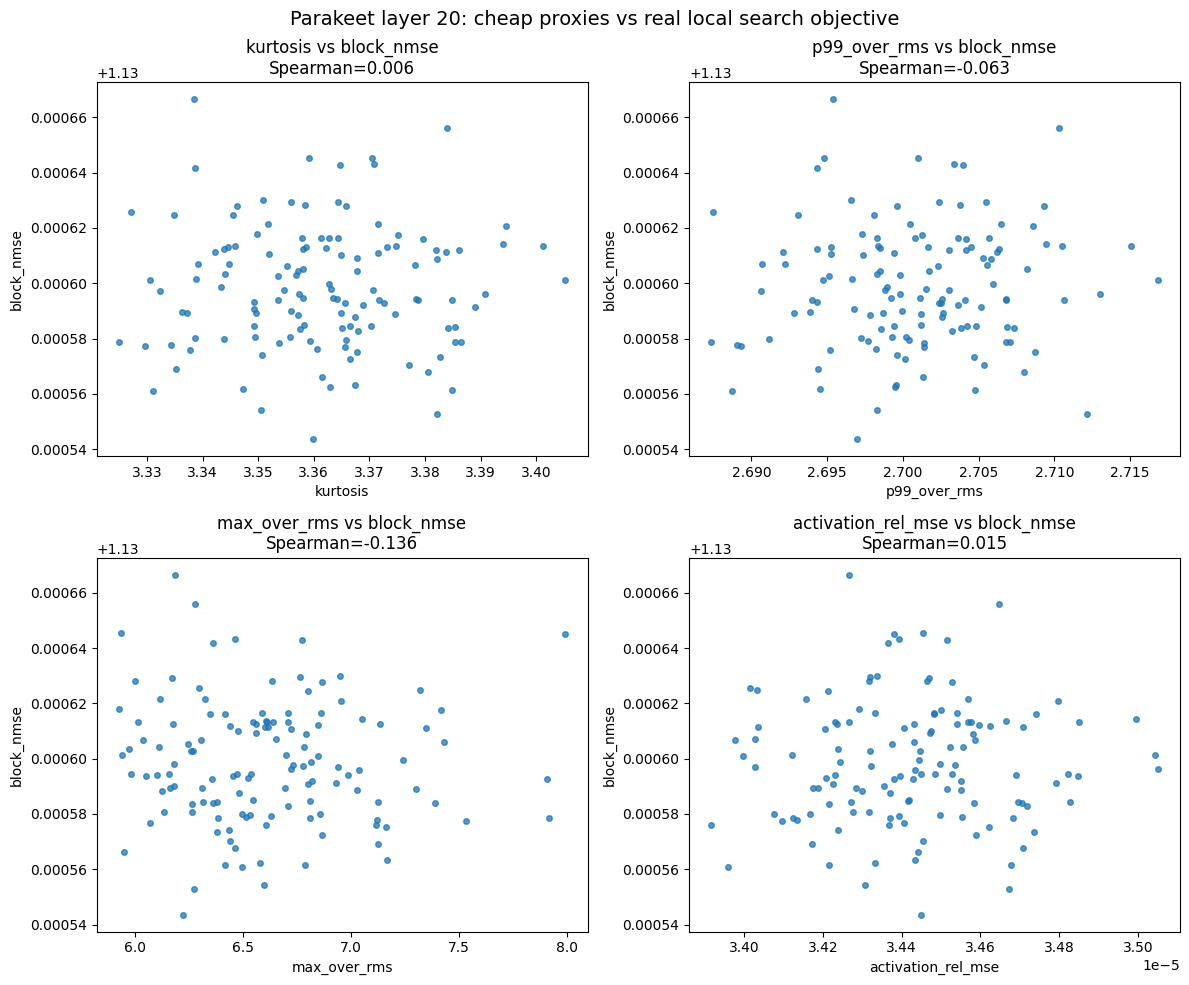

Saved scatter figure to: /home/blessedg/asrq/outputs/analysis/parakeet_q2_search_analysis/layer_20_proxy_vs_nmse.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, metric in zip(axes, metric_names):
    x = [row[metric] for row in rows]
    y = [row["block_nmse"] for row in rows]
    ax.scatter(x, y, s=16, alpha=0.75)
    ax.set_xlabel(metric)
    ax.set_ylabel("block_nmse")
    ax.set_title(f"{metric} vs block_nmse\nSpearman={correlations[metric]:.3f}")

fig.suptitle(f"Parakeet layer {LAYER_INDEX}: cheap proxies vs real local search objective", fontsize=14)
fig.tight_layout()
scatter_path = OUTPUT_DIR / f"layer_{LAYER_INDEX}_proxy_vs_nmse.png"
fig.savefig(scatter_path, dpi=180)
plt.show()
print(f"Saved scatter figure to: {scatter_path}")


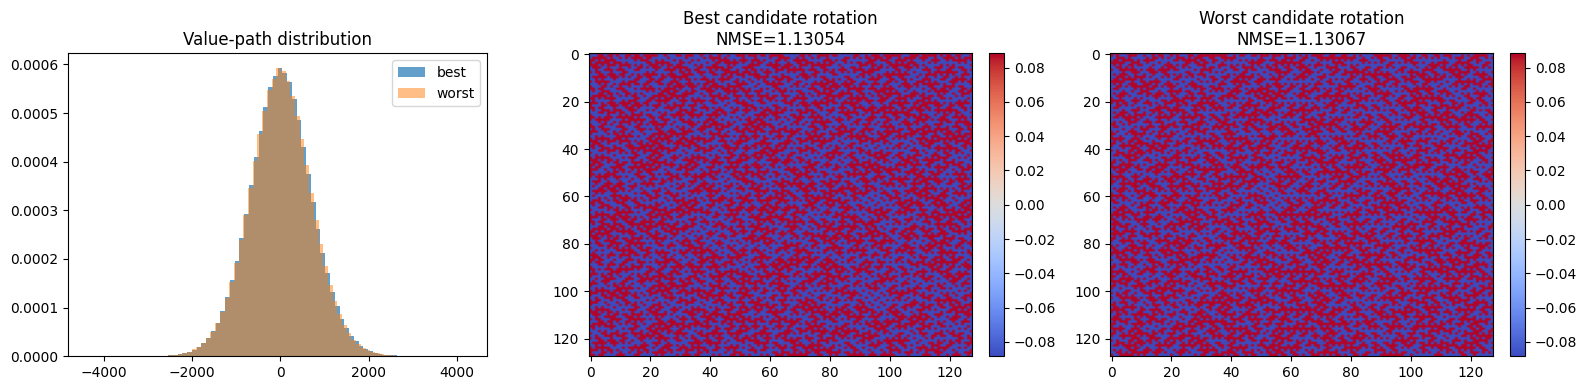

Saved qualitative figure to: /home/blessedg/asrq/outputs/analysis/parakeet_q2_search_analysis/layer_20_best_vs_worst.png
Best candidate metrics: {'candidate_index': 55, 'block_nmse': 1.1305436010275682, 'kurtosis': 3.359898328781128, 'p99_over_rms': 2.6969916820526123, 'max_over_rms': 6.22475528717041, 'activation_rel_mse': 3.444966205279343e-05, 'num_negative_s0': 67, 'num_negative_s1': 68}
Worst candidate metrics: {'candidate_index': 10, 'block_nmse': 1.1306664997583553, 'kurtosis': 3.338510751724243, 'p99_over_rms': 2.6953670978546143, 'max_over_rms': 6.186273574829102, 'activation_rel_mse': 3.42668681696523e-05, 'num_negative_s0': 65, 'num_negative_s1': 67}


In [17]:
best_row = rows[0]
worst_row = rows[-1]
best_candidate = candidates[int(best_row["candidate_index"])]
worst_candidate = candidates[int(worst_row["candidate_index"])]

best_values = value_path_tensor_for_candidate(adapter, site, best_candidate).reshape(-1).numpy()
worst_values = value_path_tensor_for_candidate(adapter, site, worst_candidate).reshape(-1).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(best_values, bins=80, alpha=0.7, label="best", density=True)
axes[0].hist(worst_values, bins=80, alpha=0.5, label="worst", density=True)
axes[0].set_title("Value-path distribution")
axes[0].legend()

best_rotation = best_candidate.to_rotation(site.base_h, device="cpu", dtype=torch.float32).numpy()
worst_rotation = worst_candidate.to_rotation(site.base_h, device="cpu", dtype=torch.float32).numpy()
im1 = axes[1].imshow(best_rotation, cmap="coolwarm", aspect="auto")
axes[1].set_title(f"Best candidate rotation\nNMSE={best_row['block_nmse']:.5f}")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
im2 = axes[2].imshow(worst_rotation, cmap="coolwarm", aspect="auto")
axes[2].set_title(f"Worst candidate rotation\nNMSE={worst_row['block_nmse']:.5f}")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

fig.tight_layout()
qual_path = OUTPUT_DIR / f"layer_{LAYER_INDEX}_best_vs_worst.png"
fig.savefig(qual_path, dpi=180)
plt.show()
print(f"Saved qualitative figure to: {qual_path}")
print("Best candidate metrics:", best_row)
print("Worst candidate metrics:", worst_row)


In [18]:
worst_rotation

array([[ 0.08838835,  0.08838835,  0.08838835, ..., -0.08838835,
        -0.08838835,  0.08838835],
       [ 0.08838835, -0.08838835,  0.08838835, ...,  0.08838835,
        -0.08838835, -0.08838835],
       [-0.08838835, -0.08838835,  0.08838835, ...,  0.08838835,
        -0.08838835,  0.08838835],
       ...,
       [-0.08838835,  0.08838835, -0.08838835, ...,  0.08838835,
        -0.08838835, -0.08838835],
       [-0.08838835, -0.08838835,  0.08838835, ..., -0.08838835,
         0.08838835, -0.08838835],
       [ 0.08838835, -0.08838835, -0.08838835, ..., -0.08838835,
        -0.08838835, -0.08838835]], shape=(128, 128), dtype=float32)